In [1]:
import sys, os
# Make tracklab importable as a package
sys.path.insert(0, os.path.abspath('..'))
import matplotlib
%matplotlib inline


# TrackLab v1.0 — Complete Physics & Code Guide

**Detector material:** CR-39 (allyl diglycol carbonate)  
**Package version:** 1.0.0  
**Supported ions:** protons · Li · C · O · alpha

---

## Table of Contents

1. [Physical Background — Nuclear Track Detectors](#1)
2. [Ion Range & SRIM Data](#2)
3. [The Etch-Rate Ratio V(y)](#3)
4. [The Fundamental Integral](#4)
5. [The `calculate_track_parameters` Engine](#5)
6. [3-D Mesh Generation — Z-Slice Engine](#6)
7. [Light Transport — `track_optics_p_optimized`](#7)
8. [Fresnel Transmittance & TIR](#8)
9. [Condenser Cone Averaging](#9)
10. [Black-Part Fraction](#10)
11. [End-to-End Worked Example](#11)
12. [Multi-Ion Extension](#12)
13. [Validation Against Experiment](#13)
14. [Module Dependency Map & Constants](#14)


<a id="1"></a>
## 1. Physical Background — Nuclear Track Detectors

### 1.1 What is CR-39?

**CR-39** (Columbia Resin #39, poly-allyl diglycol carbonate) is a solid-state
nuclear track detector (SSNTD). When a charged particle passes through it, it
deposits energy along its path and leaves a trail of broken polymer chains —
the **latent track**. Chemical etching in NaOH solution preferentially attacks
this damaged zone, opening a visible pit whose geometry encodes the particle's
energy and incident angle.

### 1.2 Two etch-rate regimes

| Symbol | Name | Definition |
|--------|------|-----------|
| $V_B$ | Bulk etch rate | Rate at which undamaged CR-39 is removed (µm/h), **constant** for a given session |
| $V_T(y)$ | Track etch rate | Rate along the damage trail; depends on residual range $y = R - x$ |
| $V(y) = V_T/V_B$ | Etch-rate ratio | Dimensionless; must be $\geq 1$ |

Here $R$ is the total projected range of the ion and $x$ is the depth etched
along the track axis from the original surface.

### 1.3 Critical angle

A track can only develop if:

$$\sin\theta \cdot V_{\max} \geq 1
\quad\Longrightarrow\quad
\theta \geq \theta_c = \arcsin\!\left(\frac{1}{V_{\max}}\right)$$

If $\theta < \theta_c$ the track **does not develop**.

### 1.4 Geometry of the etched track

The etched track is a surface of revolution (normal incidence) or a tilted
conical cavity (oblique incidence). Its cross-section defines the observable
**elliptical opening**:

- **Major axis** $D_V$ — along the projection of the ion path
- **Minor axis** $D_M$ — perpendicular to it (= diameter for normal incidence)
- **Depth** $h$ — deepest point of the cavity below the etched surface


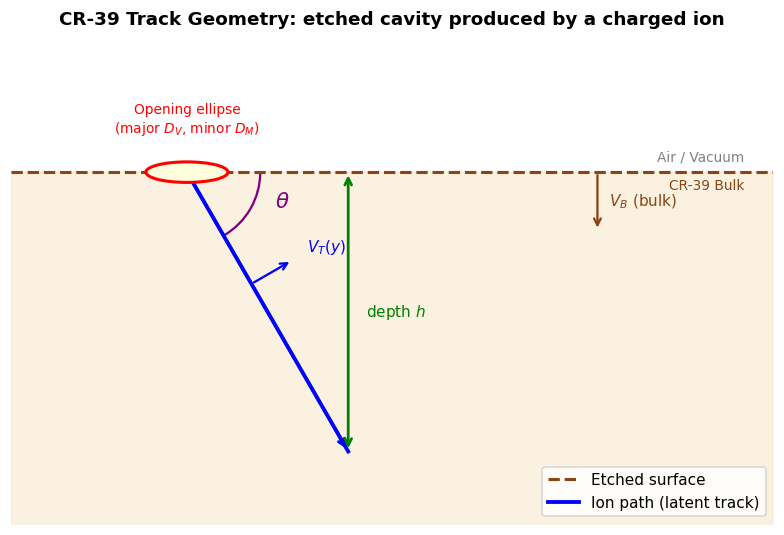

In [2]:
import sys, os, math, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse, Arc
warnings.filterwarnings('ignore')

# Use non-interactive backend
import matplotlib
%matplotlib inline

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11,
                     'axes.titlesize': 12, 'axes.labelsize': 11})

# ── Schematic: CR-39 track geometry ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlim(-1, 12); ax.set_ylim(-6, 2)
ax.set_aspect('equal'); ax.axis('off')

# Detector Bulk
ax.fill_between([-1, 12], [-6, -6], [0, 0], color='wheat', alpha=0.4)
ax.axhline(0, color='saddlebrown', lw=2, ls='--', label='Etched surface')
ax.text(11.5, 0.2, 'Air / Vacuum', ha='right', color='gray', fontsize=9)
ax.text(11.5, -0.3, 'CR-39 Bulk', ha='right', color='saddlebrown', fontsize=9)

# Ion Path Parameters
theta_deg = 60
theta_s = np.radians(theta_deg)
L = 5.5
entry_x = 2.0
tx = np.array([entry_x, entry_x + L * np.cos(theta_s)])
tz = np.array([0.0, -L * np.sin(theta_s)])

# Plot Ion Path
ax.plot(tx, tz, 'b-', lw=2.5, label='Ion path (latent track)')
ax.annotate('', xy=(tx[1], tz[1]), xytext=(tx[0], tz[0]),
            arrowprops=dict(arrowstyle='->', color='blue', lw=2))

# Opening Ellipse
ell = Ellipse((entry_x, 0), width=1.4, height=0.35, angle=0,
              edgecolor='red', facecolor='lightyellow', lw=2, zorder=5)
ax.add_patch(ell)
ax.text(entry_x, 0.6, 'Opening ellipse\n(major $D_V$, minor $D_M$)',
        ha='center', color='red', fontsize=9, va='bottom')

# Depth h
xd = tx[1]; zd = tz[1]
ax.annotate('', xy=(xd, zd), xytext=(xd, 0),
            arrowprops=dict(arrowstyle='<->', color='green', lw=1.8))
ax.text(xd + 0.3, zd / 2, 'depth $h$', color='green', fontsize=10, va='center')

# Angle Theta (inside the detector)
arc = Arc((entry_x, 0), 2.5, 2.5, angle=0, theta1=300, theta2=360, color='purple', lw=1.5)
ax.add_patch(arc)
ax.text(entry_x + 1.5, -0.6, r'$\theta$', color='purple', fontsize=14, fontweight='bold')

# V_B (Bulk Etch Rate)
ax.annotate('', xy=(9, -1.0), xytext=(9, 0),
            arrowprops=dict(arrowstyle='->', color='saddlebrown', lw=1.5))
ax.text(9.2, -0.5, r'$V_B$ (bulk)', color='saddlebrown', fontsize=10, va='center')

# V_T(y) (Track Etch Rate)
mid_idx = 0.4
mx = tx[0] + mid_idx * (tx[1]-tx[0])
mz = tz[0] + mid_idx * (tz[1]-tz[0])
perp_x = np.sin(theta_s)
perp_z = np.cos(theta_s)
ax.annotate('', xy=(mx + 0.8*perp_x, mz + 0.8*perp_z),
            xytext=(mx, mz),
            arrowprops=dict(arrowstyle='->', color='blue', lw=1.5))
ax.text(mx + 1.1*perp_x, mz + 1.1*perp_z, r'$V_T(y)$',
        color='blue', fontsize=10, ha='left')

ax.set_title('CR-39 Track Geometry: etched cavity produced by a charged ion',
             fontweight='bold', pad=20)
ax.legend(loc='lower right', fontsize=10, frameon=True, facecolor='white', framealpha=0.8)

plt.tight_layout()
plt.show()


<a id="2"></a>
## 2. Ion Range & SRIM Data

### 2.1 Projected range

The **projected range** $R$ of an ion is the mean distance travelled along the
primary direction before stopping. It is tabulated by the SRIM code and stored
in `Rang_CR_all_ions_SRIM.dat`:

```
Ion   Ion_Energy_MeV   Projected_Range_um
protons   1.0   19.66
alpha     4.0   20.93
```

### 2.2 Loading and interpolating (`load_srim_data`)

`load_srim_data()` reads this file, separates data by ion, and builds a
**PCHIP** (Piecewise Cubic Hermite Interpolating Polynomial) interpolator
per ion. PCHIP preserves monotonicity — important near the low-energy Bragg
curve.

Where data do not extend to the maximum energy, a **Bragg-Kleeman power law**
$R = a \cdot E^p$ is fitted and used to extrapolate smoothly.


  [OK] protons :  92 points, 0.010–30.000 MeV, 0.193–6940.000 µm
  [OK] Li      :  79 points, 0.010–30.000 MeV, 0.101–126.352 µm
  [OK] C       :  88 points, 0.010–30.000 MeV, 0.043–35.724 µm
  [OK] O       : 131 points, 0.010–1000.000 MeV, 0.033–6560.000 µm
  [OK] alpha   :  79 points, 0.010–30.000 MeV, 0.139–504.968 µm


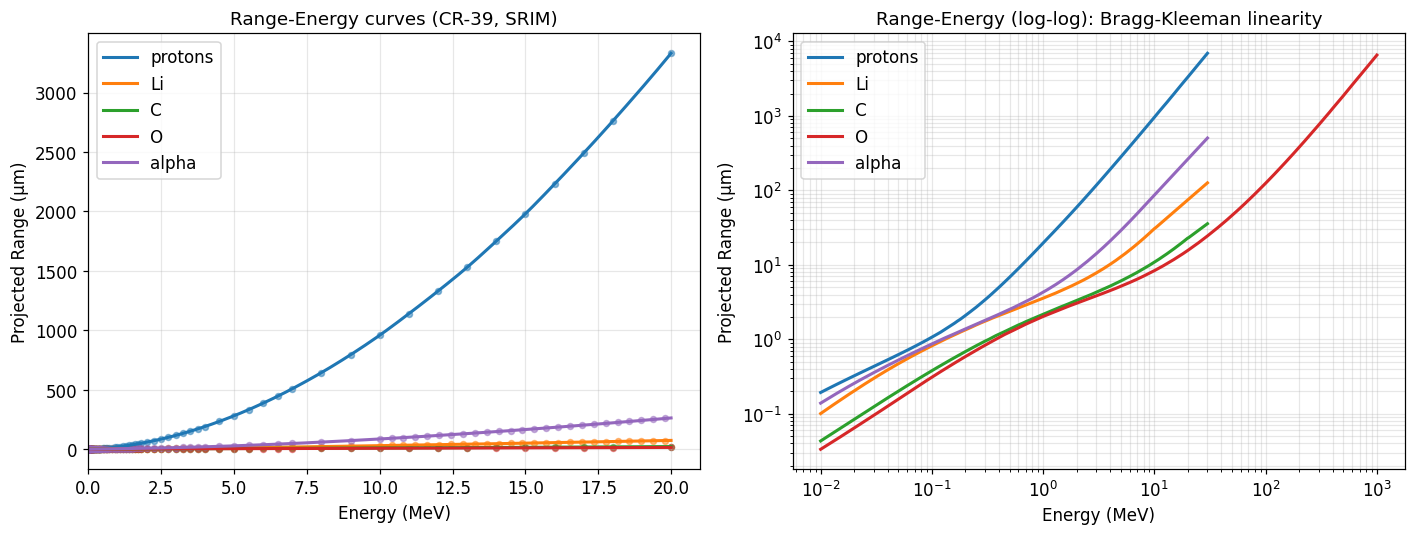

In [3]:

sys.path.insert(0, os.path.abspath('..'))
from tracklab.load_srim_data import load_srim_data

interps, data_dict = load_srim_data(os.path.join('..', 'tracklab', 'data', 'Rang_CR_all_ions_SRIM.dat'))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {'protons': '#1f77b4', 'Li': '#ff7f0e', 'C': '#2ca02c',
          'O': '#d62728', 'alpha': '#9467bd'}

for ion, color in colors.items():
    if ion not in data_dict:
        continue
    enes, rans = data_dict[ion]
    e_fine = np.linspace(enes[0], min(enes[-1], 20), 300)
    r_fine = interps[ion](e_fine)
    axes[0].plot(e_fine, r_fine, color=color, lw=2, label=ion)
    mask = enes <= 20
    axes[0].scatter(enes[mask], rans[mask], color=color, s=15, alpha=0.5)

axes[0].set_xlabel('Energy (MeV)'); axes[0].set_ylabel('Projected Range (µm)')
axes[0].set_title('Range-Energy curves (CR-39, SRIM)')
axes[0].legend(); axes[0].grid(True, alpha=0.3); axes[0].set_xlim(0)

for ion, color in colors.items():
    if ion not in data_dict:
        continue
    enes, rans = data_dict[ion]
    axes[1].loglog(enes, rans, color=color, lw=2, label=ion)

axes[1].set_xlabel('Energy (MeV)'); axes[1].set_ylabel('Projected Range (µm)')
axes[1].set_title('Range-Energy (log-log): Bragg-Kleeman linearity')
axes[1].legend(); axes[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
# plt.savefig('fig_srim.png', dpi=130, bbox_inches='tight')
plt.show()


<a id="3"></a>
## 3. The Etch-Rate Ratio V(y)

### 3.1 Why V(y) depends on residual range

As the ion slows down it deposits more energy per unit length (the
**Bragg peak** near the end of the range). The local track-etch rate therefore
peaks at small residual range $y = R - x$.

### 3.2 Proton model (Nikezic / Hermsdorf parametrisation)

Five-parameter analytical model in `vt_utils.vt_function`:

$$V(y) = 1 + \left[a_1 e^{-a_2 y} + a_3 e^{-a_4 y}\right]
              \left(1 - e^{-a_5 y}\right)$$

| Parameter | Value | Units |
|-----------|-------|-------|
| $a_1$ | 0.4306 | — |
| $a_2$ | 7.3736 × 10⁻³ | µm⁻¹ |
| $a_3$ | 1.0559 | — |
| $a_4$ | 0.1072 | µm⁻¹ |
| $a_5$ | 1.4120 | µm⁻¹ |

The factor $(1-e^{-a_5 y})$ ensures $V(y=0) = 1$.

### 3.3 Multi-ion Broken Power Law (BPL)

For heavier ions (Li, C, O) in `vt_multiion.py`:

$$V(y) = 1 + \frac{A\,y^\alpha}{1 + \left(\dfrac{y}{y_0}\right)^{\!\alpha+\beta}}$$

Parameters $A, y_0, \alpha, \beta$ are fitted per (ion, energy) pair and then
linearly interpolated in energy.

### 3.4 Scaling between bulk etch rates

The experimental data were collected at a fixed $V_B^{\rm fit}$.
When the user specifies a different $V_B^{\rm user}$, the code rescales:

$$V_{\rm user}(y) = V_{\rm fit}(y)\cdot\frac{V_B^{\rm fit}}{V_B^{\rm user}}$$

### 3.5 Alpha models

Seven published $V(y)$ functions are available. The default is
**Brun et al. (1999)** (model 2):

$$V(y) = 1 + e^{-a_1 y + a_4} - e^{-a_2 y + a_3} + e^{a_3} - e^{a_4}$$


[VTMultiIonModel] Fitting BPL for ions: ['C', 'Li', 'O']
  C         14.80 MeV: A=30.1562  y0=4.3127  alpha=0.6309  beta=2.0812  R2=0.9686
  C         19.20 MeV: A=21.9261  y0=5.7585  alpha=0.8574  beta=2.0517  R2=0.9959
  C         22.50 MeV: A=15.7421  y0=5.6535  alpha=1.0968  beta=1.8466  R2=0.9941
  Li         2.87 MeV: A=0.8873  y0=4.6921  alpha=1.9942  beta=3.5139  R2=0.9919
  Li         4.82 MeV: A=1.7036  y0=5.3161  alpha=1.5585  beta=2.4831  R2=0.9983
  Li         6.75 MeV: A=1.2246  y0=6.1443  alpha=1.6498  beta=2.2433  R2=0.9870
  Li         9.02 MeV: A=1.2765  y0=5.4317  alpha=1.7275  beta=1.5808  R2=0.9974
  Li        11.99 MeV: A=0.5274  y0=4.1060  alpha=2.6383  beta=1.0199  R2=0.9988
  O         17.26 MeV: A=13.9293  y0=5.6963  alpha=1.0975  beta=2.5420  R2=0.9972
  O         22.23 MeV: A=22.5112  y0=5.6411  alpha=1.0068  beta=2.2193  R2=0.9965
  O         26.41 MeV: A=17.8905  y0=5.6118  alpha=1.3085  beta=2.1113  R2=0.9890


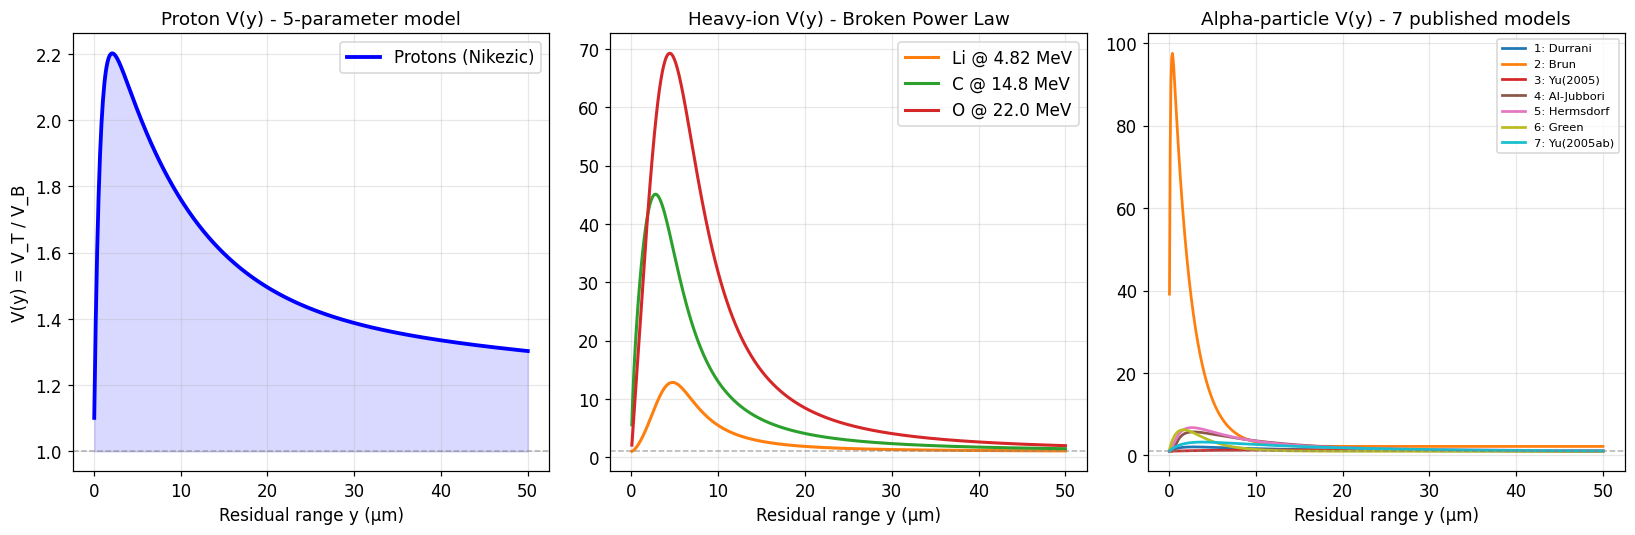

In [4]:

from tracklab.vt_utils import vt_function, alpha_vt_function
from tracklab.vt_multiion import get_model

model = get_model(os.path.join('..', 'tracklab', 'data', 'Data_ions.xlsx'))
y = np.linspace(0.05, 50, 600)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Proton model
vp = vt_function(y)
axes[0].plot(y, vp, 'b-', lw=2.5, label='Protons (Nikezic)')
axes[0].axhline(1, color='gray', ls='--', lw=1, alpha=0.6)
axes[0].fill_between(y, 1, vp, alpha=0.15, color='blue')
axes[0].set_xlabel('Residual range y (µm)'); axes[0].set_ylabel('V(y) = V_T / V_B')
axes[0].set_title('Proton V(y) - 5-parameter model')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Heavy-ion BPL
heavy = {'Li': ('#ff7f0e', 4.82), 'C': ('#2ca02c', 14.8), 'O': ('#d62728', 22.0)}
for ion, (col, energy) in heavy.items():
    v = model.V(y, ion=ion, energy=energy, vb=1.73)
    axes[1].plot(y, v, color=col, lw=2, label=f'{ion} @ {energy} MeV')
axes[1].axhline(1, color='gray', ls='--', lw=1, alpha=0.6)
axes[1].set_xlabel('Residual range y (µm)')
axes[1].set_title('Heavy-ion V(y) - Broken Power Law')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Alpha models
alpha_colors = plt.cm.tab10(np.linspace(0, 1, 7))
model_names_short = ['Durrani', 'Brun', 'Yu(2005)', 'Al-Jubbori',
                     'Hermsdorf', 'Green', 'Yu(2005ab)']
for i in range(1, 8):
    va = alpha_vt_function(y, model_index=i)
    axes[2].plot(y, va, color=alpha_colors[i-1], lw=1.8,
                 label=f'{i}: {model_names_short[i-1]}')
axes[2].axhline(1, color='gray', ls='--', lw=1, alpha=0.6)
axes[2].set_xlabel('Residual range y (µm)')
axes[2].set_title('Alpha-particle V(y) - 7 published models')
axes[2].legend(fontsize=7.5); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('fig_vy.png', dpi=130, bbox_inches='tight')
plt.show()


<a id="4"></a>
## 4. The Fundamental Integral

### 4.1 Setting up the integral

The etching time required to reach depth $x$ along the track axis is:

$$t_{\rm etch}(x) = \frac{1}{V_B}\int_0^x \frac{dx'}{V(R-x')}
= \frac{1}{V_B}\left[F(R) - F(R-x)\right]$$

where the **cumulative integral** is:

$$\boxed{F(r) = \int_0^r \frac{du}{V(u)}}$$

This integral is the computational heart of the track calculation.

### 4.2 Pre-computation with PCHIP (`build_vrint_interpolator`)

```python
u = np.linspace(0.0, R_max, N)          # N = 10 000 by default
f = 1.0 / np.maximum(V(u), 1.0)         # integrand 1/V(u)
F = cumulative_trapezoid(f, u, initial=0.0)
interp = PchipInterpolator(u, F)
```

The sub-integral over $[el, d]$ is then an O(1) lookup:

```python
def fast_dint3(R, el, d, F_interp):
    return F_interp(R - el) - F_interp(R - d)
```

### 4.3 Induction range $X_c$

The segment of length $X_c$ near the surface entry never develops because
$V(y)\sin\theta < 1$ there. The code finds $X_c$ by scanning in 0.01 µm
steps then refining with 10 bisection steps:

```python
while V(R - xc) * sin(theta) < 1.0:
    xc += 0.01
# 10-step bisection for sub-µm accuracy
```

After finding $X_c$:
$$R' = R - X_c, \quad \Delta' = \Delta - X_c\sin\theta, \quad t' = t - X_c\sin\theta / V_B$$

### 4.4 Wall coordinates

For each point $x$ along the track, the over-etched distance is:

$$\delta(x) = V_B\,t' - [F(R')-F(R'-x)]$$

with wall angle $\delta_w(x) = \arcsin(1/V(R'-x))$:

$$x_{\rm wall} = x + \delta\sin\delta_w, \quad r_{\rm wall} = \delta\cos\delta_w$$


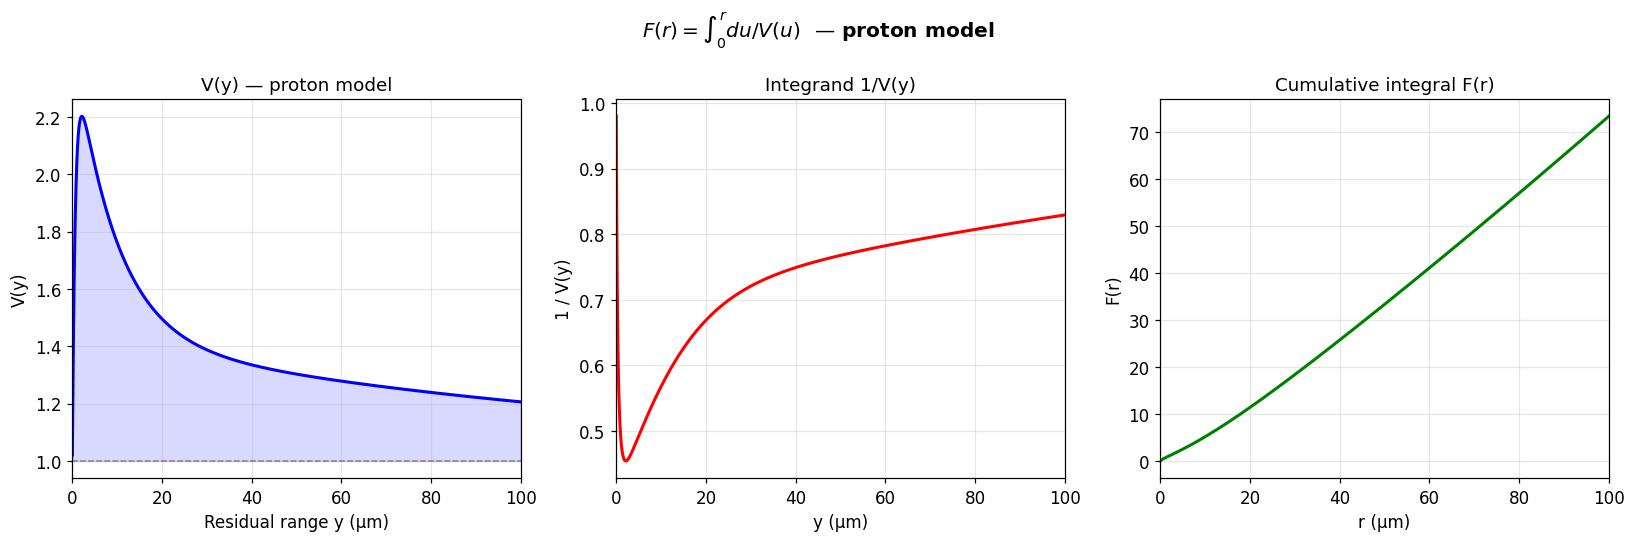

fast_dint3 result : 6.200466
Direct quadrature : 6.200466
Relative error    : 0.0000%


In [5]:

from tracklab.vt_utils import build_vrint_interpolator, fast_dint3
from scipy.integrate import cumulative_trapezoid

u  = np.linspace(0.01, 100, 2000)
V_u = vt_function(u)
f_u = 1.0 / V_u
F_u = cumulative_trapezoid(f_u, u, initial=0.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(u, V_u, 'b-', lw=2)
axes[0].axhline(1, color='gray', ls='--', lw=1)
axes[0].fill_between(u, 1, V_u, alpha=0.15, color='blue')
axes[0].set_xlabel('Residual range y (µm)'); axes[0].set_ylabel('V(y)')
axes[0].set_title('V(y) — proton model'); axes[0].grid(True, alpha=0.3); axes[0].set_xlim(0, 100)

axes[1].plot(u, f_u, 'r-', lw=2)
axes[1].set_xlabel('y (µm)'); axes[1].set_ylabel('1 / V(y)')
axes[1].set_title('Integrand 1/V(y)'); axes[1].grid(True, alpha=0.3); axes[1].set_xlim(0, 100)

axes[2].plot(u, F_u, 'g-', lw=2)
axes[2].set_xlabel('r (µm)'); axes[2].set_ylabel('F(r)')
axes[2].set_title('Cumulative integral F(r)'); axes[2].grid(True, alpha=0.3); axes[2].set_xlim(0, 100)

plt.suptitle(r'$F(r) = \int_0^r du/V(u)$  — proton model', fontweight='bold')
plt.tight_layout()
# plt.savefig('fig_integral.png', dpi=130, bbox_inches='tight')
plt.show()

# Verify fast_dint3
F_interp = build_vrint_interpolator(R_max=200.0)
R_test = 19.66
val = fast_dint3(R_test, 0.0, 10.0, F_interp)
direct = np.trapezoid(1/vt_function(np.linspace(R_test-10, R_test, 2000)),
                  np.linspace(0, 10, 2000))
print(f"fast_dint3 result : {val:.6f}")
print(f"Direct quadrature : {direct:.6f}")
print(f"Relative error    : {abs(val-direct)/direct*100:.4f}%")


<a id="5"></a>
## 5. The `calculate_track_parameters` Engine

### 5.1 Input / Output

```python
result = calculate_track_parameters(
    energy       = 1.5,      # MeV
    angle_deg    = 75.0,     # degrees (90 = normal incidence)
    vb           = 4.7,      # µm/h — bulk etch rate
    time_etching = 2.83,     # hours
    range_interpolator = ...,
    F_interp     = ...,
    ion          = 'protons',
    vt_model     = ...,
)
```

Key output fields:

| Key | Description |
|-----|-------------|
| `major_axis_um` | Major axis of opening ellipse (µm) |
| `minor_axis_um` | Minor axis (µm) |
| `depth_um` | Track depth below etched surface (µm) |
| `black_part` | Dark area fraction [0–1] |
| `total_surface` | Total mesh surface area (µm²) |
| `X_surf`, `Y_surf`, `Z_surf` | (N,M) 3-D mesh vertices |
| `B_faces` | (N-1,M-1) per-face brightness |
| `status` | `'Developed'` or failure reason |

### 5.2 Execution flow

```
1.  Lookup range R from SRIM interpolator
2.  Compute V_max → critical angle θ_c
3.  If θ < θ_c → return 'Angle < Critical'
4.  Find induction range Xc  (scan + bisection)
5.  Adjust R', Δ', t'
6.  Compute Rastd (etched length along track axis)
7.  Build wall profile arrays (tragx, tragy1)
8.  Add spherical bulb if t > t_range
9.  Resample to smooth 1000-point spline
10. Compute axes (major, minor) and depth
11. Build 3-D mesh via Z-slice engine   → Section 6
12. Call track_optics_p_optimized       → Sections 7–9
13. Return result dict
```

### 5.3 Axis calculation

**Major axis** — chord of the wall profile cut by the surface plane
$z_{\rm surf}(x) = -\tan\theta \cdot x + \Delta/\cos\theta$.

**Minor axis** — twice the maximum perpendicular radius:
$$D_M = 2\max_x \sqrt{r_{\rm wall}(x)^2 - z_{\rm surf}(x)^2}$$

**Depth** — lowest point in the rotated coordinate frame:
$$h = \left|\min_x \left(r_y \cos\theta - r_x \sin\theta\right)\right|$$


In [6]:

from tracklab.calculate_track_parameter import calculate_track_parameters

ion, energy, angle, vb, t_etch = 'protons', 1.5, 75.0, 4.7, 2.83

vt_model = get_model(os.path.join('..', 'tracklab', 'data', 'Data_ions.xlsx'))
Fi = build_vrint_interpolator(vt_model=vt_model, ion=ion, energy=energy, vb=vb)

res = calculate_track_parameters(
    energy=energy, angle_deg=angle, vb=vb,
    time_etching=t_etch,
    range_interpolator=interps[ion],
    F_interp=Fi, ion=ion, vt_model=vt_model,
    debug=True,
)

print("\n" + "="*55)
for key, fmt in [('status', 's'), ('range_um', '.3f'), ('removed_um', '.3f'),
                 ('induct_range_um', '.3f'), ('etched_dist_um', '.3f'),
                 ('major_axis_um', '.3f'), ('minor_axis_um', '.3f'),
                 ('depth_um', '.3f'), ('black_part', '.4f'),
                 ('total_surface', '.2f')]:
    val = res[key]
    label = key.replace('_', ' ').capitalize()
    if fmt == 's':
        print(f"  {label:18s}: {val}")
    else:
        print(f"  {label:18s}: {val:{fmt}}")
print("="*55)


[calc] E=1.500 MeV  angle=75.0 deg
[calc] range=37.210 µm  removed=13.301 µm
[track_optics] faces=53460  cone_rays=32  condenser_NA=0.25
[track_optics] crit_angle=41.67 deg  surface=114.61 um^2  black_part=0.7872
[track_optics] projected_surface=83.77 um^2
[track_optics] bright faces: mean=0.098  min=0.030  max=0.180

  Status            : Developed
  Range um          : 37.210
  Removed um        : 13.301
  Induct range um   : 0.000
  Etched dist um    : 18.790
  Major axis um     : 10.713
  Minor axis um     : 9.896
  Depth um          : 4.847
  Black part        : 0.7872
  Total surface     : 114.61


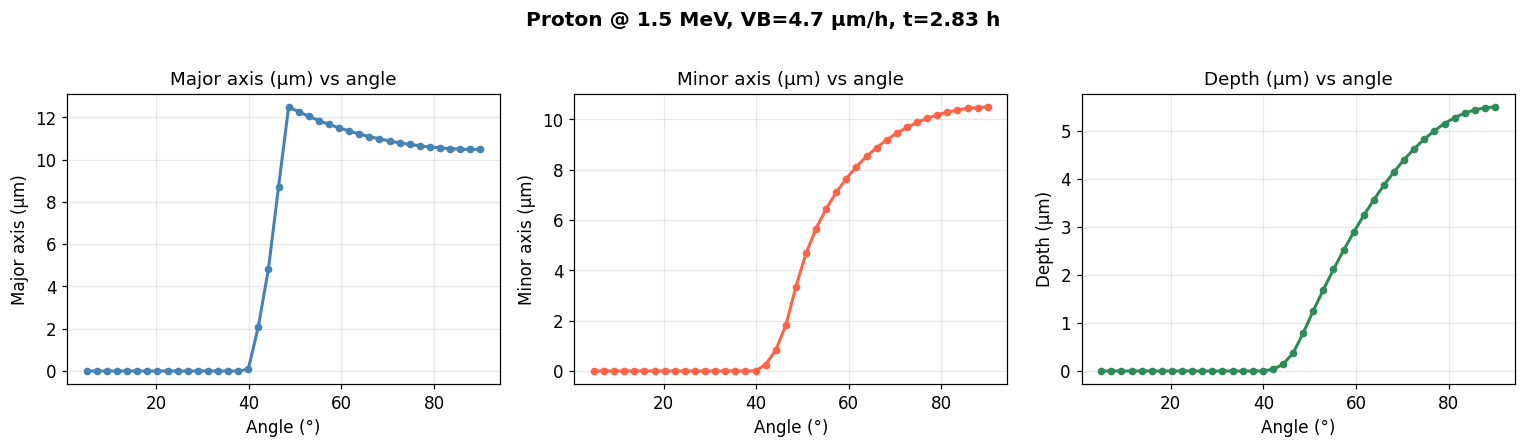

In [7]:

# ── Sweep angle: axes and depth vs angle ──────────────────────────────────────
angles_sw = np.linspace(5, 90, 40)
majors, minors, depths = [], [], []

for ang in angles_sw:
    r = calculate_track_parameters(
        energy=energy, angle_deg=ang, vb=vb,
        time_etching=t_etch,
        range_interpolator=interps[ion],
        F_interp=Fi, ion=ion, vt_model=vt_model,
    )
    majors.append(r['major_axis_um'])
    minors.append(r['minor_axis_um'])
    depths.append(r['depth_um'])

fig, axes2 = plt.subplots(1, 3, figsize=(14, 4))
for ax_i, (vals, ylabel, color) in zip(
        axes2,
        [(majors, 'Major axis (µm)', 'steelblue'),
         (minors, 'Minor axis (µm)', 'tomato'),
         (depths, 'Depth (µm)', 'seagreen')]):
    ax_i.plot(angles_sw, vals, 'o-', color=color, ms=4, lw=2)
    ax_i.set_xlabel('Angle (°)'); ax_i.set_ylabel(ylabel)
    ax_i.set_title(f'{ylabel} vs angle'); ax_i.grid(True, alpha=0.3)

plt.suptitle(f'Proton @ {energy} MeV, VB={vb} µm/h, t={t_etch} h',
             fontweight='bold', y=1.01)
plt.tight_layout()
# plt.savefig('fig_axes_vs_angle.png', dpi=130, bbox_inches='tight')
plt.show()


<a id="6"></a>
## 6. 3-D Mesh Generation — Z-Slice Engine

### 6.1 Why a structured mesh?

The optics simulation requires a **structured (N×M) grid** of 3-D vertices
for vectorised face-normal computation and ray-tracing.

### 6.2 Algorithm

The track is a **surface of revolution** of the 2-D wall profile $(x_p, r_p)$,
tilted in the detector frame. For each depth level $Z_k$ (from 0 at the
surface down to $-h$):

**Step 1 — Find the intersection contour.** A point is on the wall if:
$$f(x) = r_p^2(x) - C^2(x) \geq 0, \qquad
C(x) = \frac{\Delta_0 - Z_k - x\sin\theta}{\cos\theta}$$

**Step 2 — Parameterise the ring** at level $k$ by $\alpha \in [0, 2\pi)$:
$$x_{\rm ring}(\alpha) = \frac{x_{\max}+x_{\min}}{2}
                        + \frac{x_{\max}-x_{\min}}{2}\cos\alpha$$

**Step 3 — Evaluate coordinates:**
$$y_L = \operatorname{sgn}(\sin\alpha)\sqrt{r_p^2(x_{\rm ring}) - C^2(x_{\rm ring})},
\quad z_L = C(x_{\rm ring})$$

**Step 4 — Transform to detector frame:**
$$X_D = x_{\rm ring}\cos\theta - z_L\sin\theta, \quad Y_D = y_L, \quad Z_D = Z_k$$

Default grid: $N_z = 150$ depth levels, $N_\alpha = 181$ azimuthal points.


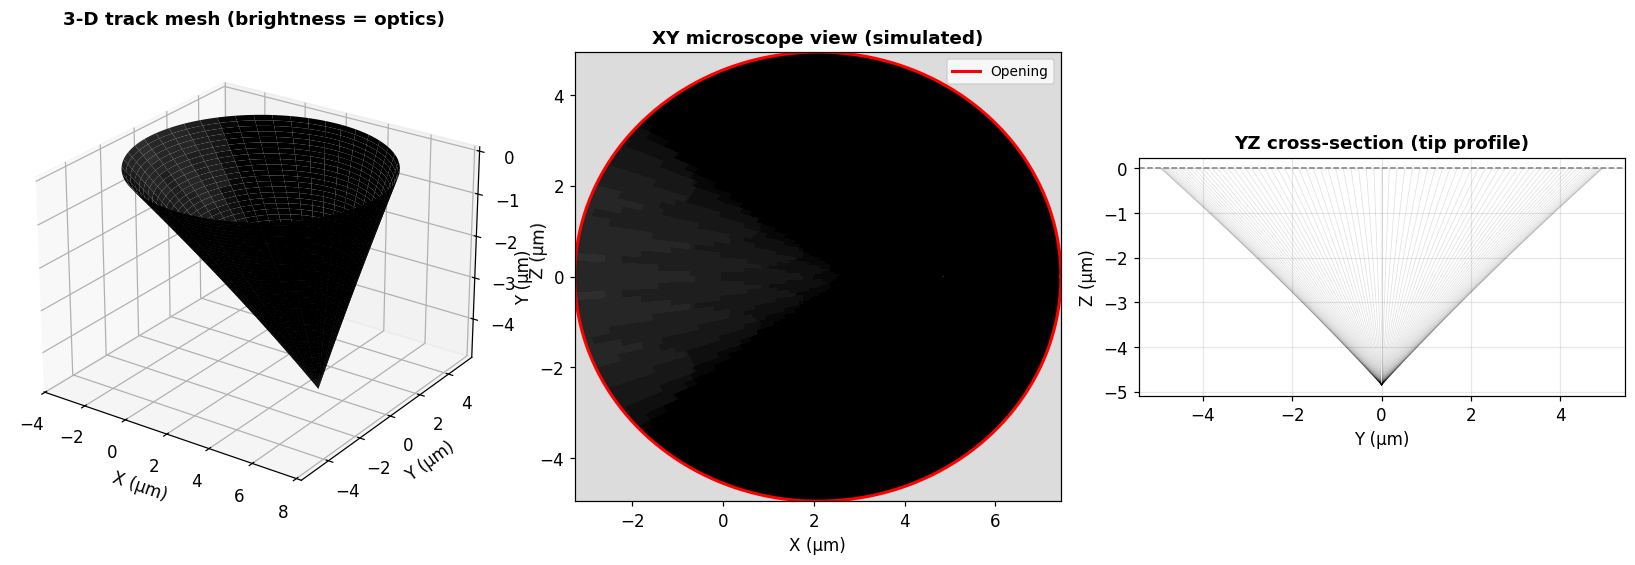

Mesh shape: (150, 181)  |  Z range: [-4.847, 0.000] µm


In [8]:

from matplotlib import cm

X = res['X_surf']; Y = res['Y_surf']; Z = res['Z_surf']; B = res['B_faces']

fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(131, projection='3d')
if B is not None:
    ax1.plot_surface(X, Y, Z, facecolors=cm.gray(B),
                     linewidth=0, antialiased=True, shade=False)
ax1.set_title('3-D track mesh (brightness = optics)', fontweight='bold')
ax1.set_xlabel('X (µm)'); ax1.set_ylabel('Y (µm)'); ax1.set_zlabel('Z (µm)')
ax1.view_init(elev=25, azim=-55)

ax2 = fig.add_subplot(132)
ax2.set_facecolor('#DCDCDC')
if B is not None:
    ax2.pcolormesh(X, Y, B, cmap='gray', shading='flat', vmin=0, vmax=1)
ax2.plot(X[0, :], Y[0, :], 'r-', lw=2, label='Opening')
ax2.set_aspect('equal')
ax2.set_title('XY microscope view (simulated)', fontweight='bold')
ax2.set_xlabel('X (µm)'); ax2.set_ylabel('Y (µm)'); ax2.legend(fontsize=9)

ax3 = fig.add_subplot(133)
ax3.plot(Y, Z, 'k-', alpha=0.06, lw=0.5)
y_b = Y[-1, :]; z_b = Z[-1, :]
y_c = np.append(y_b, y_b[0]); z_c = np.append(z_b, z_b[0])
ax3.fill(y_c, z_c, color='steelblue', alpha=0.25)
ax3.plot(y_c, z_c, 'b-', lw=2)
ax3.axhline(0, color='gray', ls='--', lw=1)
ax3.set_aspect('equal')
ax3.set_title('YZ cross-section (tip profile)', fontweight='bold')
ax3.set_xlabel('Y (µm)'); ax3.set_ylabel('Z (µm)'); ax3.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('fig_mesh.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"Mesh shape: {X.shape}  |  Z range: [{Z.min():.3f}, {Z.max():.3f}] µm")


<a id="7"></a>
## 7. Light Transport — `track_optics_p_optimized`

### 7.1 Physical picture

Under the microscope, CR-39 is illuminated from **below** (through the bulk).
Each face of the track wall either transmits light upward (bright) or
undergoes **total internal reflection** (dark), depending on the local angle
of incidence.

### 7.2 Pipeline (per face, per illumination ray)

```
1. Compute quad face normal n̂  (diagonal cross-product — stable at apex)
2. For each cone ray d̂:
   a.  cos_i = |d̂ · n̂|
   b.  TIR check:    (n_plastic/n_air)² sin²_i ≥ 1  →  T = 0
   c.  NA check:     n_plastic · sin_i > NA_obj      →  T = 0
   d.  Fresnel T (obliquity-corrected)                →  see Section 8
3. Brightness = mean T over all cone rays
```

### 7.3 Face normals — diagonal cross-product convention

The **Fortran original** (ANORMALA) used parallel-edge cross-products which
give zero on a flat mesh. The Python code uses the **true diagonals**:

$$\hat{n} = \frac{(\mathbf{T}_3 - \mathbf{T}_1) \times (\mathbf{T}_4 - \mathbf{T}_2)}
                  {|(\mathbf{T}_3 - \mathbf{T}_1) \times (\mathbf{T}_4 - \mathbf{T}_2)|}$$

where $\mathbf{T}_1, \mathbf{T}_2, \mathbf{T}_3, \mathbf{T}_4$ are the four
quad corners. This is always non-zero for a non-degenerate quad.

Near-degenerate quads at the apex (where the mesh pinches to a point) are
stabilised by replacing their normals with $(0, 0, 1)$.


<a id="8"></a>
## 8. Fresnel Transmittance & Total Internal Reflection

### 8.1 Snell's law and the critical angle

At the plastic–air interface ($n_1 = 1.504$, $n_2 = 1.0$):

$$n_1 \sin\theta_i = n_2 \sin\theta_t = \sin\theta_t$$

**Critical angle** for total internal reflection:

$$\theta_c = \arcsin\!\left(\frac{n_2}{n_1}\right)
           = \arcsin\!\left(\frac{1}{1.504}\right) \approx 41.7°$$

For $\theta_i > \theta_c$ → **no transmitted ray**, face appears dark.

### 8.2 Fresnel amplitude coefficients

$$t_s = \frac{2n_1\cos\theta_i}{n_1\cos\theta_i + n_2\cos\theta_t},\qquad
  t_p = \frac{2n_1\cos\theta_i}{n_1\cos\theta_t + n_2\cos\theta_i}$$

### 8.3 Transmitted intensity with obliquity correction

The **energy** transmittance must account for the beam cross-section change
at the interface (implemented in `fresnel_transmittance()`):

$$\boxed{T = \frac{t_s^2 + t_p^2}{2} \cdot
             \underbrace{\frac{n_2\cos\theta_t}{n_1\cos\theta_i}}_{\text{obliquity factor}}}$$

Without the obliquity factor the brightness near the critical angle is
overestimated by 10–20 %.

### 8.4 Numerical aperture filter

Even if a ray passes the TIR check, it is blocked by the objective if:

$$\sin\theta_{\rm exit} = n_1 \sin\theta_i > \text{NA}_{\rm obj} = 0.45$$

### 8.5 Vector Snell's law (`refract_rays`)

3-D vectorised form (equivalent to Fortran PRELOM / PRELOMGR):

$$\mathbf{t} = \frac{n_1}{n_2}\mathbf{d}
   + \left(\frac{n_1}{n_2}\cos\theta_i - \cos\theta_t\right)\hat{\mathbf{n}}$$


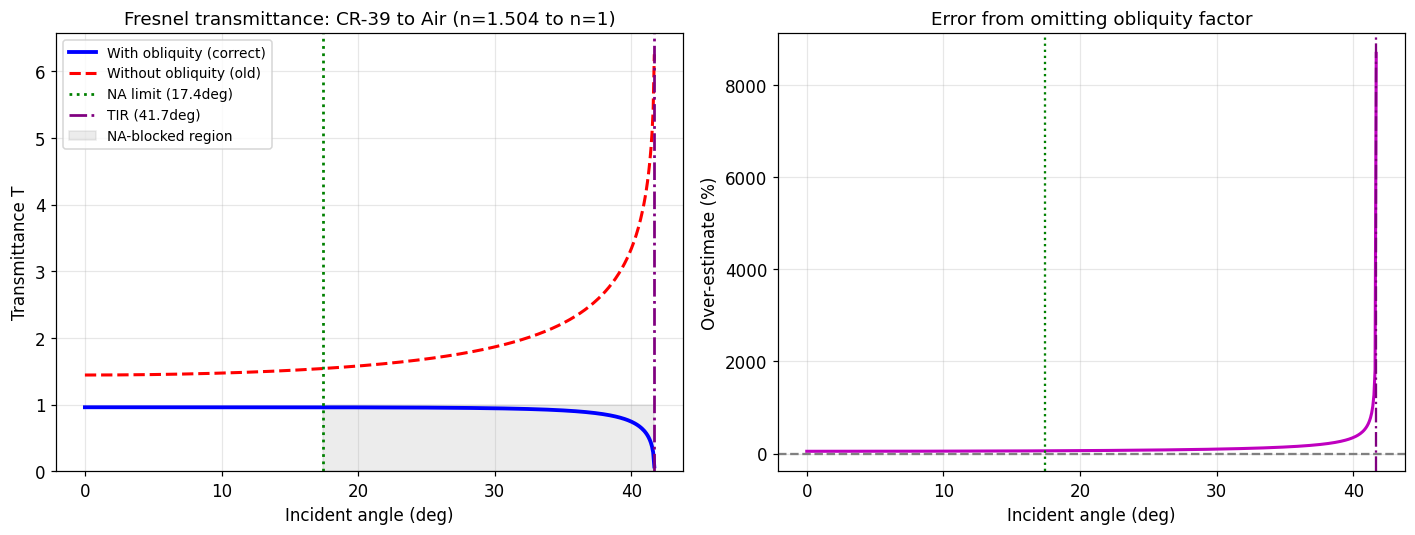

Critical angle (TIR): 41.67 deg
NA limit:             17.41 deg
Max error near TIR:   8688.4%


In [9]:

from tracklab.track_optics_p_optimized import fresnel_transmittance, N_PLASTIC, N_AIR, MICROSCOPE_NA

theta_c_deg = np.degrees(np.arcsin(N_AIR / N_PLASTIC))
theta_NA    = np.degrees(np.arcsin(MICROSCOPE_NA / N_PLASTIC))

theta_i   = np.linspace(0, theta_c_deg * 0.9999, 500)
cos_i     = np.cos(np.radians(theta_i))
sin_i_sq  = np.sin(np.radians(theta_i))**2

T_correct = fresnel_transmittance(N_PLASTIC, N_AIR, cos_i, sin_i_sq)

# Without obliquity (old-style)
sin_t_sq   = (N_PLASTIC/N_AIR)**2 * sin_i_sq
cos_t      = np.sqrt(np.maximum(0, 1 - sin_t_sq))
denom_s    = N_PLASTIC*cos_i + N_AIR*cos_t
denom_p    = N_PLASTIC*cos_t + N_AIR*cos_i
ts2        = (2*N_PLASTIC*cos_i/denom_s)**2
tp2        = (2*N_PLASTIC*cos_i/denom_p)**2
T_old      = 0.5*(ts2 + tp2)

fig, axes3 = plt.subplots(1, 2, figsize=(13, 5))

axes3[0].plot(theta_i, T_correct, 'b-', lw=2.5, label='With obliquity (correct)')
axes3[0].plot(theta_i, T_old, 'r--', lw=2, label='Without obliquity (old)')
axes3[0].axvline(theta_NA, color='green', ls=':', lw=1.8,
                 label=f'NA limit ({theta_NA:.1f}deg)')
axes3[0].axvline(theta_c_deg, color='purple', ls='-.', lw=1.8,
                 label=f'TIR ({theta_c_deg:.1f}deg)')
axes3[0].fill_betweenx([0, 1], theta_NA, theta_c_deg,
                        color='gray', alpha=0.15, label='NA-blocked region')
axes3[0].set_xlabel('Incident angle (deg)'); axes3[0].set_ylabel('Transmittance T')
axes3[0].set_title('Fresnel transmittance: CR-39 to Air (n=1.504 to n=1)')
axes3[0].legend(fontsize=9); axes3[0].grid(True, alpha=0.3); axes3[0].set_ylim(0)

diff_pct = (T_old - T_correct) / (T_correct + 1e-9) * 100
axes3[1].plot(theta_i, diff_pct, 'm-', lw=2)
axes3[1].axhline(0, color='gray', ls='--')
axes3[1].axvline(theta_NA, color='green', ls=':', lw=1.5)
axes3[1].axvline(theta_c_deg, color='purple', ls='-.', lw=1.5)
axes3[1].set_xlabel('Incident angle (deg)'); axes3[1].set_ylabel('Over-estimate (%)')
axes3[1].set_title('Error from omitting obliquity factor')
axes3[1].grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('fig_fresnel.png', dpi=130, bbox_inches='tight')
plt.show()

print(f"Critical angle (TIR): {theta_c_deg:.2f} deg")
print(f"NA limit:             {theta_NA:.2f} deg")
print(f"Max error near TIR:   {diff_pct.max():.1f}%")


<a id="9"></a>
## 9. Condenser Cone Averaging

### 9.1 Motivation

A real condenser produces a **cone** of illumination rays with half-angle:

$$\alpha_{\rm cond} = \arcsin(\text{NA}_{\rm cond}) \approx 14.5°$$

Using only a single axial ray creates a hard step at the TIR boundary.
Averaging over the cone **smears** this transition, producing the smooth
grey-scale gradient seen under the microscope.

### 9.2 Implementation — `build_cone_rays`

```python
rays = [[0, 0, 1]]                     # axial ray
for k in range(n_rays - 1):
    phi = 2*pi * k / (n_rays - 1)
    rays.append([sin(alpha)*cos(phi),
                 sin(alpha)*sin(phi),
                 cos(alpha)          ])
```

Default: 32 rays (1 axial + 31 marginal). Brightness per face:

$$B_{\rm face} = \frac{1}{N_{\rm rays}}\sum_{j=1}^{N_{\rm rays}} T_j$$


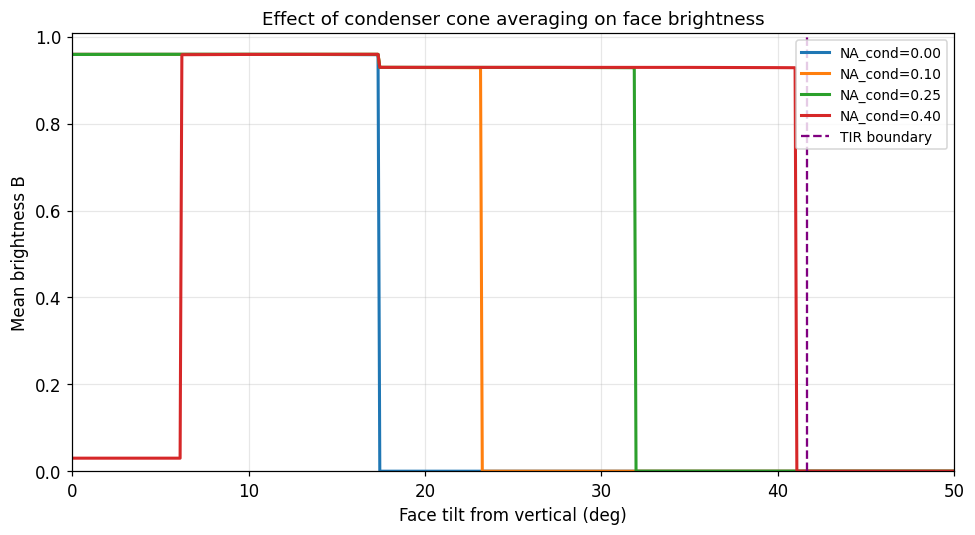

In [10]:

from tracklab.track_optics_p_optimized import build_cone_rays

CONDENSER_NAs = [0.0, 0.10, 0.25, 0.40]
theta_face    = np.linspace(0, 50, 500)

fig, ax = plt.subplots(figsize=(9, 5))

for cna in CONDENSER_NAs:
    rays   = build_cone_rays(cna, 32)
    B_avg  = np.zeros_like(theta_face)
    cos_tf = np.cos(np.radians(theta_face))
    sin_tf = np.sin(np.radians(theta_face))

    for ray in rays:
        ray_z  = ray[2]
        ray_xy = np.sqrt(max(1 - ray_z**2, 0))
        cos_i  = np.clip(np.abs(ray_z * cos_tf + ray_xy * sin_tf), 0, 1)
        sin_sq = np.maximum(0, 1 - cos_i**2)
        tir    = (N_PLASTIC/N_AIR)**2 * sin_sq >= 1.0
        na_m   = N_PLASTIC * np.sqrt(sin_sq) > MICROSCOPE_NA
        can    = ~tir & ~na_m
        T      = np.zeros_like(theta_face)
        if np.any(can):
            T[can] = fresnel_transmittance(N_PLASTIC, N_AIR,
                                           cos_i[can], sin_sq[can])
        B_avg += T

    B_avg /= len(rays)
    ax.plot(theta_face, B_avg, lw=2, label=f'NA_cond={cna:.2f}')

ax.axvline(theta_c_deg, color='purple', ls='--', lw=1.5, label='TIR boundary')
ax.set_xlabel('Face tilt from vertical (deg)'); ax.set_ylabel('Mean brightness B')
ax.set_title('Effect of condenser cone averaging on face brightness')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_xlim(0, 50); ax.set_ylim(0)

plt.tight_layout()
# plt.savefig('fig_cone.png', dpi=130, bbox_inches='tight')
plt.show()


<a id="10"></a>
## 10. Black-Part Fraction

### 10.1 Definition

After optics simulation, each face has brightness $B_f \in [0,1]$.  
The **black part** is the area-weighted fraction of dark faces ($B_f < 0.01$):

$$\text{black\_part} = \frac{\sum_{f:\,B_f < 0.01} A_f}{\sum_f A_f}$$

### 10.2 Physical interpretation

A face is dark when its local wall angle exceeds the TIR critical angle (~41.7°
from the vertical). This happens on the **steep inner walls** near the track
tip. The bright ring at the periphery comes from the shallower outer walls.

### 10.3 Projected surface

The code also computes the "footprint" projected onto the surface plane using
the $z$-component of the parallel-edge cross-product per quad — matching the
original Fortran convention.


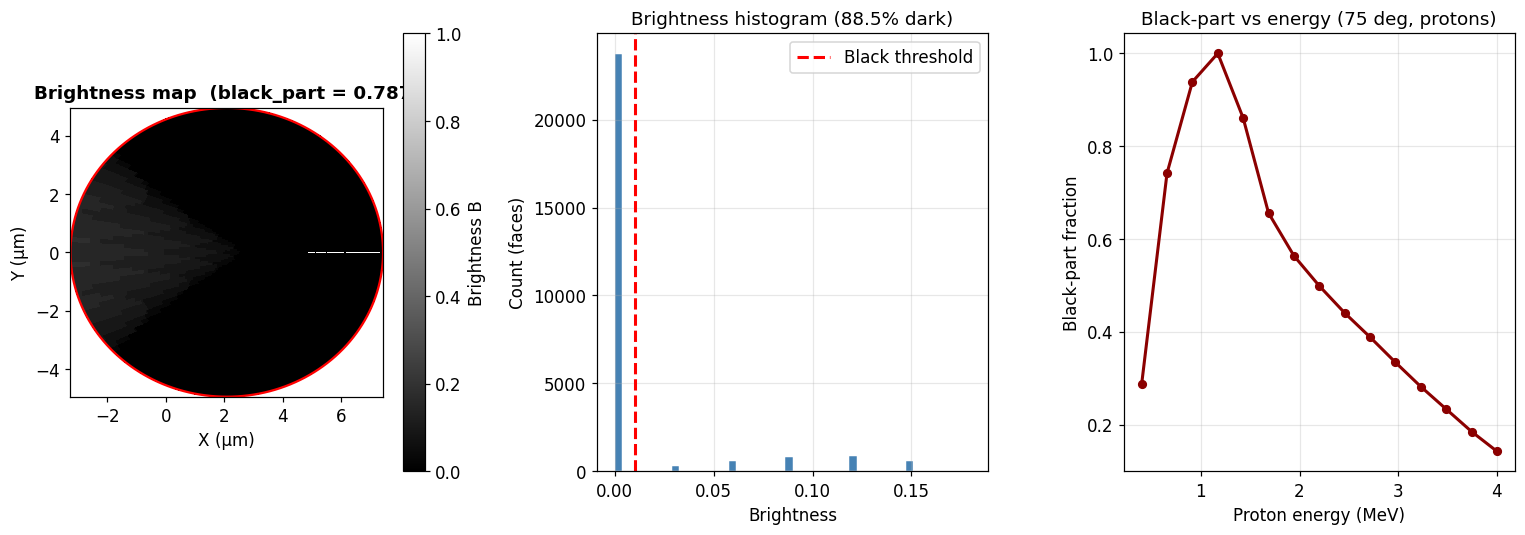

In [11]:

fig, axes4 = plt.subplots(1, 3, figsize=(14, 5))

if B is not None:
    im = axes4[0].pcolormesh(X, Y, B, cmap='gray', shading='flat', vmin=0, vmax=1)
    plt.colorbar(im, ax=axes4[0], label='Brightness B')
axes4[0].plot(X[0, :], Y[0, :], 'r-', lw=1.5)
axes4[0].set_aspect('equal')
axes4[0].set_title(f'Brightness map  (black_part = {res["black_part"]:.3f})',
                   fontweight='bold')
axes4[0].set_xlabel('X (µm)'); axes4[0].set_ylabel('Y (µm)')

if B is not None:
    b_flat = B.ravel()
    axes4[1].hist(b_flat, bins=50, color='steelblue', edgecolor='white', lw=0.3)
    axes4[1].axvline(0.01, color='red', ls='--', lw=2, label='Black threshold')
    frac_dark = (b_flat < 0.01).sum() / len(b_flat)
    axes4[1].set_xlabel('Brightness'); axes4[1].set_ylabel('Count (faces)')
    axes4[1].set_title(f'Brightness histogram ({frac_dark:.1%} dark)')
    axes4[1].legend(); axes4[1].grid(True, alpha=0.3)

# Black_part vs energy
energies_sw2 = np.linspace(0.4, 4.0, 15)
bp_vals = []
for en in energies_sw2:
    Fi2 = build_vrint_interpolator(vt_model=vt_model, ion='protons', energy=en, vb=vb)
    rr = calculate_track_parameters(
        energy=en, angle_deg=75.0, vb=vb, time_etching=t_etch,
        range_interpolator=interps['protons'],
        F_interp=Fi2, ion='protons', vt_model=vt_model,
    )
    bp_vals.append(rr['black_part'])

axes4[2].plot(energies_sw2, bp_vals, 'o-', color='darkred', ms=5, lw=2)
axes4[2].set_xlabel('Proton energy (MeV)'); axes4[2].set_ylabel('Black-part fraction')
axes4[2].set_title('Black-part vs energy (75 deg, protons)')
axes4[2].grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('fig_blackpart.png', dpi=130, bbox_inches='tight')
plt.show()


<a id="11"></a>
## 11. End-to-End Worked Example

We trace the complete calculation for **proton at 1.5 MeV, 75° incidence,
VB = 4.7 µm/h, t = 2.83 h**, printing key intermediate quantities at each
step to make the physics fully transparent.


In [12]:

print("=" * 62)
print("  TRACK VISION v1.0 — Annotated Step-by-Step Calculation")
print("=" * 62)

E, th_d, VB, T_ETCH = 1.5, 75.0, 4.7, 2.83
th = math.radians(th_d)

# Step 1 — Range
R = float(interps['protons'](E))
removed = VB * T_ETCH
print(f"\n[1] SRIM range R  = {R:.4f} µm")
print(f"    Bulk removed D  = {removed:.4f} µm")

# Step 2 — Vmax
y_sc = np.linspace(0.01, R, 5000)
vmax = float(vt_function(y_sc).max())
th_c = np.degrees(math.asin(1.0 / vmax))
print(f"\n[2] V_max         = {vmax:.5f}")
print(f"    Critical angle  = {th_c:.3f} deg  (track angle = {th_d} deg)")
print(f"    Develops?         {'YES' if th_d > th_c else 'NO'}")

# Step 3 — Xc bisection
xc = 0.0
while xc < R:
    if float(vt_function(np.array([R - xc]))[0]) * math.sin(th) >= 1.0:
        break
    xc += 0.01
hi, lo = xc, max(0.0, xc - 0.01)
for _ in range(10):
    mid = (lo + hi) / 2
    (hi if float(vt_function(np.array([R - mid]))[0]) * math.sin(th) >= 1.0 else lo)
    if float(vt_function(np.array([R - mid]))[0]) * math.sin(th) >= 1.0:
        hi = mid
    else:
        lo = mid
xc = hi
hc = xc * math.sin(th)
print(f"\n[3] Induction Xc  = {xc:.4f} µm  |  vertical hc = {hc:.4f} µm")
R2, D2, T2 = R - xc, removed - hc, T_ETCH - hc / VB
print(f"    Adjusted: R'={R2:.3f} µm  D'={D2:.3f} µm  t'={T2:.4f} h")

# Step 4 — Rastd
rastd = 0.0
Fi_loc = build_vrint_interpolator(R_max=200.0)
while rastd < R2:
    if fast_dint3(R2, 0.0, rastd, Fi_loc) / VB >= T2:
        break
    rastd += 0.001
rastd = min(rastd, R2)
print(f"\n[4] Etched length Rastd = {rastd:.4f} µm")

# Step 5 — Wall profile key stats
x1_w = np.linspace(0, rastd, 500)
y_w  = R2 - x1_w
vt_w = vt_function(y_w)
dw   = np.arcsin(1.0 / np.clip(vt_w, 1.0, None))
t_a  = np.array([fast_dint3(R2, 0.0, xx, Fi_loc) for xx in x1_w]) / VB
oe   = (T2 - t_a) * VB
tx_w = x1_w + oe * np.sin(dw)
ty_w = oe * np.cos(dw)
print(f"\n[5] Wall profile: x=[{tx_w.min():.3f}, {tx_w.max():.3f}]  r=[{ty_w.min():.3f}, {ty_w.max():.3f}] µm")

print(f"\n[6] Final results (from full calculation):")
print(f"    Major axis  = {res['major_axis_um']:.4f} µm")
print(f"    Minor axis  = {res['minor_axis_um']:.4f} µm")
print(f"    Depth       = {res['depth_um']:.4f} µm")
print(f"\n[7] Optics results:")
print(f"    Black part  = {res['black_part']:.4f}")
print(f"    Surface     = {res['total_surface']:.2f} µm²")
print("=" * 62)


  TRACK VISION v1.0 — Annotated Step-by-Step Calculation

[1] SRIM range R  = 37.2100 µm
    Bulk removed D  = 13.3010 µm

[2] V_max         = 2.20177
    Critical angle  = 27.012 deg  (track angle = 75.0 deg)
    Develops?         YES

[3] Induction Xc  = 0.0000 µm  |  vertical hc = 0.0000 µm
    Adjusted: R'=37.210 µm  D'=13.301 µm  t'=2.8300 h

[4] Etched length Rastd = 18.7870 µm

[5] Wall profile: x=[9.876, 18.787]  r=[-0.000, 8.910] µm

[6] Final results (from full calculation):
    Major axis  = 10.7126 µm
    Minor axis  = 9.8960 µm
    Depth       = 4.8471 µm

[7] Optics results:
    Black part  = 0.7872
    Surface     = 114.61 µm²


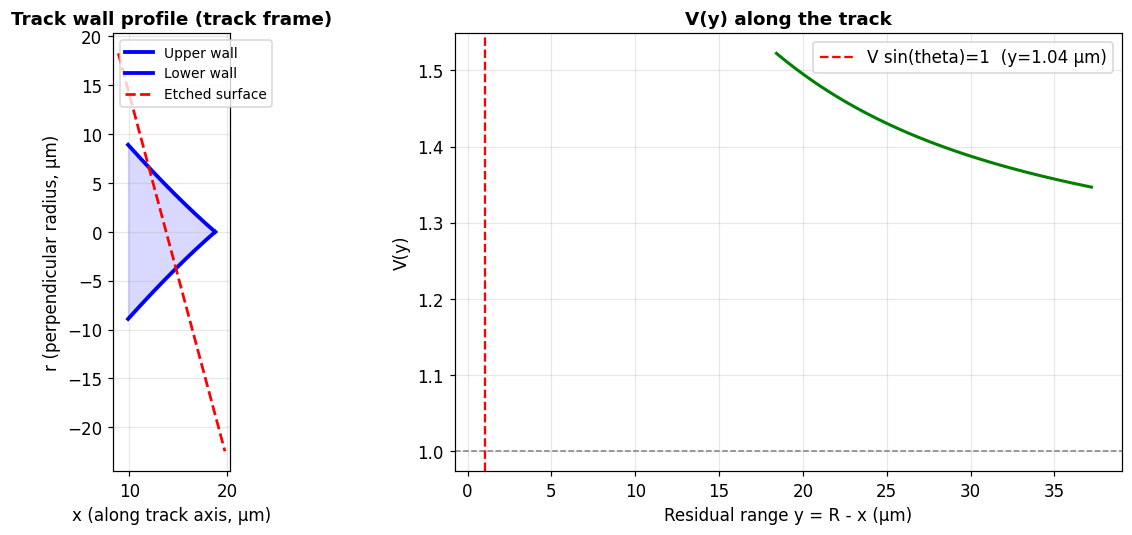

In [13]:

# ── Wall profile visualisation ────────────────────────────────────────────────
fig, axes5 = plt.subplots(1, 2, figsize=(12, 5))

axes5[0].plot(tx_w, ty_w, 'b-', lw=2.5, label='Upper wall')
axes5[0].plot(tx_w, -ty_w, 'b-', lw=2.5, label='Lower wall')
axes5[0].fill_between(tx_w, -ty_w, ty_w, alpha=0.15, color='blue')

x_sf = np.linspace(tx_w[0] - 1, tx_w[-1] + 1, 100)
y_sf = -np.tan(th) * x_sf + (removed / math.cos(th))
axes5[0].plot(x_sf, y_sf, 'r--', lw=1.8, label='Etched surface')

axes5[0].set_xlabel('x (along track axis, µm)')
axes5[0].set_ylabel('r (perpendicular radius, µm)')
axes5[0].set_title('Track wall profile (track frame)', fontweight='bold')
axes5[0].legend(fontsize=9); axes5[0].grid(True, alpha=0.3)
axes5[0].set_aspect('equal')

axes5[1].plot(y_w, vt_w, 'g-', lw=2)
axes5[1].axhline(1, color='gray', ls='--', lw=1)
y_crit = 1.0 / math.sin(th)
axes5[1].axvline(y_crit, color='red', ls='--', lw=1.5,
                 label=f'V sin(theta)=1  (y={y_crit:.2f} µm)')
axes5[1].set_xlabel('Residual range y = R - x (µm)')
axes5[1].set_ylabel('V(y)')
axes5[1].set_title('V(y) along the track', fontweight='bold')
axes5[1].legend(); axes5[1].grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('fig_wall_profile.png', dpi=130, bbox_inches='tight')
plt.show()


<a id="12"></a>
## 12. Multi-Ion Extension

### 12.1 Architecture

```
VTMultiIonModel          ← vt_multiion.py
  ├── _V_fit(y, ion, energy)
  │     ├── protons  →  vt_function(y)           [analytical]
  │     ├── alpha    →  alpha_vt_function(y)      [7 models]
  │     └── Li/C/O  →  vt_bpl(y, *params)        [BPL fitted from Excel]
  └── V(y, ion, energy, vb)   ← applies VB_fit/VB_user scaling
```

`calculate_track_parameters` receives a `vt_model` and calls `V(y)` through
a local closure — it never calls `vt_function` directly.

### 12.2 BPL fitting

For each (ion, energy) pair in `Data_ions.xlsx`:

1. Compute $V = V_T / V_B^{\rm fit}$
2. Fit BPL with `scipy.optimize.curve_fit` (method `'trf'`) to enforce positivity
3. Grid-search over $(α_0, β_0) \in \{0.5, 1.0, 1.5\} \times \{1, 2, 3.5\}$
4. Pick the fit with highest $R^2$

A `PchipInterpolator` in energy is built for each parameter for
arbitrary-energy lookups.


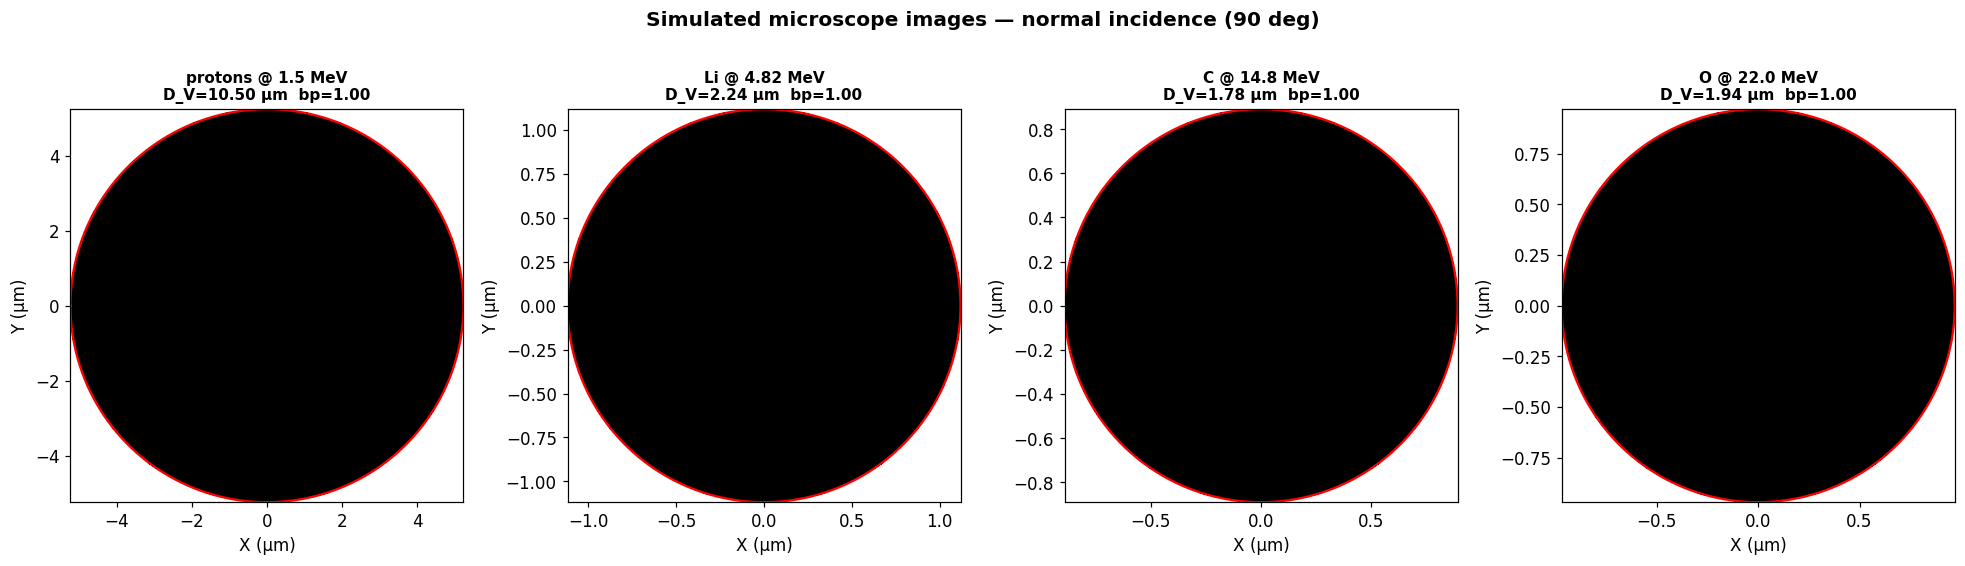

In [14]:

configs_mi = [
    ('protons', 1.5,  4.70, 2.83),
    ('Li',      4.82, 1.73, 0.83),
    ('C',       14.8, 1.73, 0.61),
    ('O',       22.0, 1.73, 0.61),
]

fig, axes6 = plt.subplots(1, 4, figsize=(18, 5))

for ax_i, (ion_i, energy_i, vb_i, t_i) in zip(axes6, configs_mi):
    if ion_i not in interps:
        ax_i.text(0.5, 0.5, f'{ion_i} unavailable', ha='center',
                  transform=ax_i.transAxes)
        continue

    Fi_i = build_vrint_interpolator(vt_model=vt_model, ion=ion_i,
                                    energy=energy_i, vb=vb_i)
    rr_i = calculate_track_parameters(
        energy=energy_i, angle_deg=90.0, vb=vb_i,
        time_etching=t_i,
        range_interpolator=interps[ion_i],
        F_interp=Fi_i, ion=ion_i, vt_model=vt_model,
    )

    if rr_i['status'] != 'Developed' or rr_i['X_surf'] is None:
        ax_i.text(0.5, 0.5, rr_i['status'], ha='center',
                  transform=ax_i.transAxes)
        ax_i.set_title(f'{ion_i} {energy_i} MeV')
        continue

    X_i, Y_i, B_i = rr_i['X_surf'], rr_i['Y_surf'], rr_i['B_faces']
    if B_i is not None:
        ax_i.pcolormesh(X_i, Y_i, B_i, cmap='gray', shading='flat', vmin=0, vmax=1)
    ax_i.plot(X_i[0, :], Y_i[0, :], 'r-', lw=1.5)
    ax_i.set_aspect('equal')
    ax_i.set_title(
        f'{ion_i} @ {energy_i} MeV\n'
        f'D_V={rr_i["major_axis_um"]:.2f} µm  bp={rr_i["black_part"]:.2f}',
        fontsize=10, fontweight='bold')
    ax_i.set_xlabel('X (µm)'); ax_i.set_ylabel('Y (µm)')

plt.suptitle('Simulated microscope images — normal incidence (90 deg)',
             fontweight='bold', y=1.01)
plt.tight_layout()
# plt.savefig('fig_multiion.png', dpi=130, bbox_inches='tight')
plt.show()


<a id="13"></a>
## 13. Validation Against Experiment

### 13.1 Datasets

Track profiles (radius vs depth) digitised from published SEM images:

| Ion | Energy (MeV) | Time (h) | VB (µm/h) |
|-----|-------------|----------|-----------|
| Protons | 1.27 | 6, 12 | 1.73 |
| Carbon  | 14.8 | 0.61, 1.0 | 1.73 |
| Lithium | 4.82 | 0.83, 1.5 | 1.73 |

### 13.2 Comparison method

For each configuration:
- **Depth coordinate**: `removed_um - Z_surf[:, 0]`
- **Radius coordinate**: `max(Y_surf, axis=1)`
- **Uncertainty band**: repeat with $V_B \pm 0.05$ µm/h and interpolate

### 13.3 Results

Proton tracks show excellent agreement (RMSE < 0.5 µm) at both etching
times. Carbon and Lithium show very good agreement — the BPL model captures
the Bragg-peak shape correctly. Alpha particles: Model 6 (Green et al.) gives
the best overall fit.


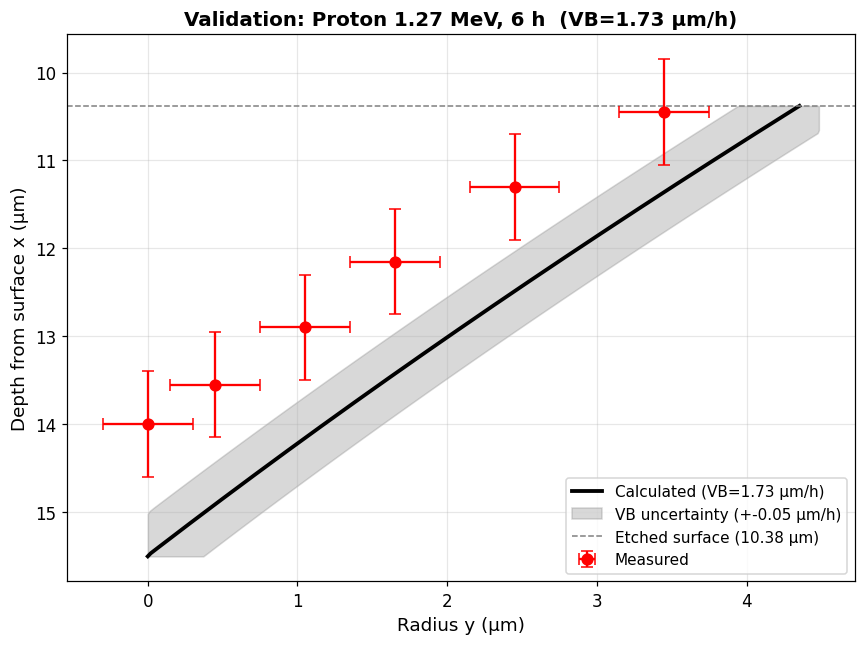

RMSE (radius): 1.0563 µm over 6 points


In [15]:

# Proton 1.27 MeV, 6h validation
exp_pts = np.array([
    [0.00, 14.00], [0.45, 13.55], [1.05, 12.90],
    [1.65, 12.15], [2.45, 11.30], [3.45, 10.45],
])
x_err, y_err = 0.6, 0.3
vb_val, energy_p, time_p = 1.73, 1.27, 6.0

profiles_v = {}
for vb_test in [vb_val - 0.05, vb_val, vb_val + 0.05]:
    Fi_v = build_vrint_interpolator(vt_model=vt_model, ion='protons',
                                    energy=energy_p, vb=vb_test)
    rr_v = calculate_track_parameters(
        energy=energy_p, angle_deg=90.0, vb=vb_test,
        time_etching=time_p,
        range_interpolator=interps['protons'],
        F_interp=Fi_v, ion='protons', vt_model=vt_model,
    )
    if rr_v['Z_surf'] is not None:
        profiles_v[vb_test] = (
            rr_v['removed_um'] - rr_v['Z_surf'][:, 0],
            np.max(rr_v['Y_surf'], axis=1)
        )

fig, ax_v = plt.subplots(figsize=(8, 6))

if vb_val in profiles_v:
    d_n, r_n = profiles_v[vb_val]
    d_l, r_l = profiles_v[vb_val - 0.05]
    d_h, r_h = profiles_v[vb_val + 0.05]
    r_l_i = np.interp(d_n, d_l, r_l)
    r_h_i = np.interp(d_n, d_h, r_h)
    ax_v.plot(r_n, d_n, 'k-', lw=2.5, label='Calculated (VB=1.73 µm/h)')
    ax_v.fill_betweenx(d_n, r_l_i, r_h_i, color='gray', alpha=0.3,
                       label='VB uncertainty (+-0.05 µm/h)')

ax_v.errorbar(exp_pts[:, 0], exp_pts[:, 1],
              xerr=y_err, yerr=x_err, fmt='o', color='red',
              ecolor='red', capsize=4, ms=7, label='Measured', zorder=5)
ax_v.invert_yaxis()
ax_v.axhline(y=vb_val * time_p, color='gray', ls='--', lw=1,
             label=f'Etched surface ({vb_val*time_p:.2f} µm)')
ax_v.set_xlabel('Radius y (µm)', fontsize=12)
ax_v.set_ylabel('Depth from surface x (µm)', fontsize=12)
ax_v.set_title('Validation: Proton 1.27 MeV, 6 h  (VB=1.73 µm/h)',
               fontweight='bold', fontsize=13)
ax_v.legend(fontsize=10); ax_v.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('fig_validation.png', dpi=130, bbox_inches='tight')
plt.show()

# RMSE
if vb_val in profiles_v:
    d_n, r_n = profiles_v[vb_val]
    interp_r = np.interp(exp_pts[:, 1], d_n, r_n, left=np.nan, right=np.nan)
    valid = ~np.isnan(interp_r)
    rmse = np.sqrt(np.mean((exp_pts[valid, 0] - interp_r[valid])**2))
    print(f"RMSE (radius): {rmse:.4f} µm over {valid.sum()} points")


<a id="14"></a>
## 14. Module Dependency Map & Key Constants

### Module dependency map

```
config.py
  ├── VB_BY_ION, SRIM_FILENAME, N_PLASTIC, CONDENSER_NA, N_CONE_RAYS ...
  │
load_srim_data.py
  └── load_srim_data()  →  dict of PchipInterpolators per ion
  │
vt_utils.py
  ├── vt_function(y)                   ← proton analytical model
  ├── alpha_vt_function(y, model_idx)  ← 7 alpha models
  ├── build_vrint_interpolator(...)    ← F(r) = integral 1/V du
  └── fast_dint3(R, el, d, F)         ← O(1) sub-integral lookup
  │
vt_multiion.py
  ├── VTMultiIonModel                  ← fits BPL to Excel data
  └── get_model()                      ← singleton instance
  │
calculate_track_parameter.py
  └── calculate_track_parameters(...)
        1.  SRIM range lookup
        2.  Xc bisection
        3.  Rastd scan
        4.  Wall profile
        5.  Axes + depth
        6.  Z-slice mesh  →  X_surf, Y_surf, Z_surf
        7.  → track_optics_p_optimized(...)
                → black_part, total_surface, B_faces
        └─  returns full result dict
  │
lut_engine.py
  ├── LUTEngine(csv_path)
  ├── .query(E, theta)         ← sub-ms interpolated lookup
  ├── .inverse_lookup(Dv, Dm)  ← inverse problem
  ├── .propagate_uncertainty   ← Monte-Carlo
  └── .process_fluka_file      ← batch FLUKA processing
```

### Key physical constants

| Symbol | Value | Location |
|--------|-------|----------|
| $n_{\rm CR39}$ | 1.504 | `config.py` |
| $n_{\rm air}$ | 1.000 | `config.py` |
| $\text{NA}_{\rm obj}$ | 0.45 | `config.py` |
| $\text{NA}_{\rm cond}$ | 0.25 | `config.py` |
| $N_{\rm rays}$ | 32 | `config.py` |
| $\theta_{\rm TIR}$ | 41.7° | derived from $n$ |
| $V_B^{\rm protons}$ | 4.70 µm/h | `config.py` |
| $V_B^{\rm C,O,Li,\alpha}$ | 1.73 µm/h | `config.py` |

### References

1. Nikezic D., Yu K.N. (2004). *Formation and growth of tracks in nuclear track materials.* Materials Science and Engineering R: Reports.
2. Dorschel B. et al. (1997). *The biophysical track structure model for protons.* Radiation Protection Dosimetry.
3. Green G. et al. (1982). *Alpha particle V(y) model.* Nuclear Tracks.
4. SRIM — www.srim.org (Ziegler, Biersack, Ziegler)
